In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "WELFake_Dataset.csv"
TARGET_COL = "label" # target column name

In [3]:
data = pd.read_csv(CSV_PATH)

In [4]:
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
data.shape

(72134, 4)

In [6]:
data = data.drop(columns=['Unnamed: 0'])

In [7]:
data.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [8]:
print(data[TARGET_COL].value_counts())
print('-'*35)
print(data[TARGET_COL].value_counts(normalize=True) * 100)

label
1    37106
0    35028
Name: count, dtype: int64
-----------------------------------
label
1   51.440
0   48.560
Name: proportion, dtype: float64


In [9]:
n_samples = 10000
# Separate Data
df_fake_news = data[data[TARGET_COL] == 0]
df_real_news = data[data[TARGET_COL] == 1]

# Sample
df_fake_sample = df_fake_news.sample(n_samples, random_state=RANDOM_STATE)
df_real_sample = df_real_news.sample(n_samples, random_state=RANDOM_STATE)

# Combine and Shuffle
df = (
        pd.concat([df_fake_sample, df_real_sample])
            .sample(frac=1, random_state=RANDOM_STATE)
            .reset_index(drop=True)
)

In [10]:
df.head()

,title,text,label
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1


In [11]:
df.shape

(20000, 3)

In [12]:
print(df[TARGET_COL].value_counts())
print('-'*35)
print(df[TARGET_COL].value_counts(normalize=True) * 100)

label
1    10000
0    10000
Name: count, dtype: int64
-----------------------------------
label
1   50.000
0   50.000
Name: proportion, dtype: float64


#### Exploratory Data Analysis (EDA)

In [13]:
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   19867 non-null  object
 1   text    19989 non-null  object
 2   label   20000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [15]:
df.isnull().sum()

title    133
text      11
label      0
dtype: int64

In [16]:
df = df.dropna()

In [17]:
df.isna().sum()

title    0
text     0
label    0
dtype: int64

In [18]:
print(df[TARGET_COL].value_counts())
print('-'*35)
print(df[TARGET_COL].value_counts(normalize=True) * 100)

label
0    10000
1     9856
Name: count, dtype: int64
-----------------------------------
label
0   50.363
1   49.637
Name: proportion, dtype: float64


### Text Cleaning

In [19]:
def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    s = re.sub(r"[^a-z0-9\s\.\,\!\?\-\']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [20]:
df['content'] = (df['title'] + " " + df['text']).apply(clean_text)

In [21]:
df.head()

,title,text,label,content
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...


In [22]:
df['title_len_chars'] = df['title'].str.len()
df['text_len_chars'] = df['text'].str.len()
df['content_len_word'] = df['content'].str.split().apply(len)

In [23]:
df.head()

,title,text,label,content,title_len_chars,text_len_chars,content_len_word
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...,134,5854,1031
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...,49,751,115
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...,55,2736,468
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...,55,1775,300
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...,100,3451,593


In [24]:
num_cols = ['title_len_chars', 'text_len_chars', 'content_len_word']

In [25]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_chars,19856.000,76.993,25.072,4.000,62.000,73.000,89.000,286.000
text_len_chars,19856.000,3283.625,3658.956,1.000,1414.750,2435.000,4081.500,115372.000
content_len_word,19856.000,558.613,621.094,0.000,243.750,414.000,687.000,21284.000


**Data Visualization**

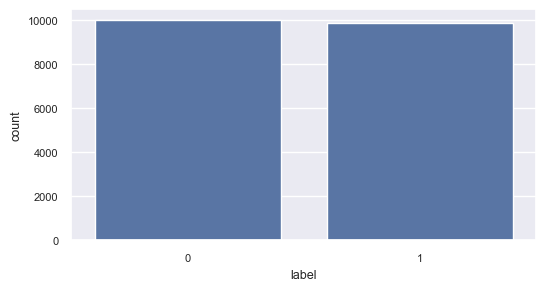

In [26]:
plt.figure(figsize=(6,3))
sns.countplot(x=TARGET_COL, data=df)
plt.show()

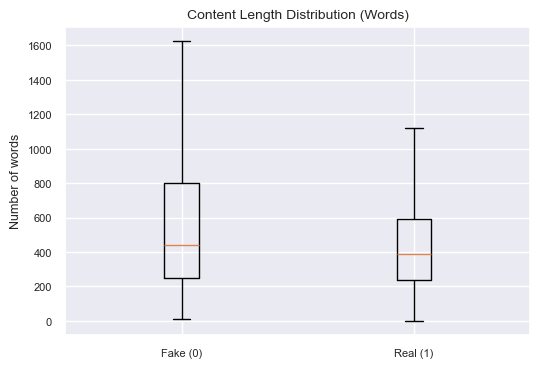

In [27]:
fake_lens = df[df[TARGET_COL] == 0]["content_len_word"].values
real_lens = df[df[TARGET_COL] == 1]["content_len_word"].values

plt.figure(figsize=(6,4))
plt.boxplot(
    [fake_lens, real_lens],
    tick_labels=["Fake (0)", "Real (1)"],
    showfliers=False
)
plt.title("Content Length Distribution (Words)")
plt.ylabel("Number of words")
plt.show()

In [28]:
X = df['content']
y = df[TARGET_COL]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
    stratify=y,
    test_size=0.2
)

In [30]:
print("\nTrain size:", len(X_train), "| Test size:", len(X_test))


Train size: 15884 | Test size: 3972


In [32]:
model_pipe = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=50_000, ngram_range=(1,2), stop_words="english", min_df=2)),
        ("model", LogisticRegression())
    ]
)

In [34]:
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('model', LogisticRegression())])

**Model Evaluation**

In [36]:
y_pred_train = model_pipe.predict(X_train)
y_prob_train = model_pipe.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("Train Metrics: ")
print(f"Accuracy: {acc_train}")

print("\nConfusion Matrix:")
print(cm_train)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_train, digits=4))

Train Metrics: 
Accuracy: 0.959456056408965

Confusion Matrix:
[[7629  371]
 [ 273 7611]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9655    0.9536    0.9595      8000
           1     0.9535    0.9654    0.9594      7884

    accuracy                         0.9595     15884
   macro avg     0.9595    0.9595    0.9595     15884
weighted avg     0.9595    0.9595    0.9595     15884



In [37]:
y_pred_test = model_pipe.predict(X_test)
y_prob_test = model_pipe.predict_proba(X_test)[:, 1]

acc_test = accuracy_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print("Test Metrics: ")
print(f"Accuracy: {acc_test}")

print("\nConfusion Matrix:")
print(cm_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

Test Metrics: 
Accuracy: 0.9352970795568983

Confusion Matrix:
[[1862  138]
 [ 119 1853]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9399    0.9310    0.9354      2000
           1     0.9307    0.9397    0.9352      1972

    accuracy                         0.9353      3972
   macro avg     0.9353    0.9353    0.9353      3972
weighted avg     0.9353    0.9353    0.9353      3972



**Predictive System**

In [39]:
def predict_news(title, text):
    combined = clean_text(f"{title} {text}")
    print(f"combined : {combined}")
    prediction = model_pipe.predict([combined])
    print(f"prediction : {prediction}")
    if prediction[0] == 1:
        print("✅ This is a Real News")
    else:
        print("❌ This is a Fake News")

In [40]:
# Example prediction
example_title = "Breaking: Government announces new economic policy"
example_text = "The finance minister introduced a new policy today after discussions in parliament..."
predict_news(example_title, example_text)

combined : breaking government announces new economic policy the finance minister introduced a new policy today after discussions in parliament...
prediction : [1]
✅ This is a Real News
